# 06 — HR Source Selection

> **This notebook uses SYNTHETIC data** written in the *exact* on-disk formats of
> three public wearable datasets (BigIdeasLab_STEP, GalaxyPPG, PPG-DaLiA), so the
> same adapters load real data unchanged.

**Problem.** Given multiple wearable HR readings for the same time window, pick the
source closest to an ECG / Polar reference. We frame it as **multiclass**: one row
per window, features for every canonical source, label = index of the *best
available* source (`argmin_s |hr_s - reference_hr|`).

**Pipeline.** synthetic generators → dataset adapters → per-window feature table →
`HistGradientBoostingClassifier` (subject-wise `GroupKFold`) → evaluation against
single-device and cross-source-median baselines.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from hr_selection import config
from hr_selection.synthetic import generate_all
from hr_selection.features.build import build_feature_table
from hr_selection.models.classical import train_classical
from hr_selection.evaluate import evaluate

sns.set_theme(style="whitegrid", palette="Set2")

## 1. Generate the synthetic datasets

A shared physiological model produces ground-truth HR + motion per subject. The
reference tracks truth; each device adds bias, motion-correlated error (worse during
activity), lag, dropouts, and (BigIdeas) skin-tone degradation. Raw-signal datasets
get synthesized ECG/PPG/ACC waveforms.

In [2]:
manifest = generate_all()
print("seed:", manifest["seed"], "| window", manifest["window_sec"], "s / shift", manifest["shift_sec"], "s")
for name, info in manifest["datasets"].items():
    print(f"  {name:10s} ref={info['reference']:10s} subjects={info['n_subjects']} sources={info['sources']}")
print("\nInjected failure modes:")
for fm in manifest["failure_modes"]:
    print("  -", fm)

seed: 42 | window 8.0 s / shift 2.0 s
  bigideas   ref=ECG        subjects=8 sources=['apple_watch', 'empatica', 'garmin', 'fitbit', 'miband', 'biovotion']
  galaxyppg  ref=PolarH10   subjects=4 sources=['galaxy_watch', 'e4']
  ppg_dalia  ref=chest ECG  subjects=4 sources=['dalia_wrist']

Injected failure modes:
  - device bias (constant per-device offset)
  - motion-correlated error (worse during Activity)
  - reporting lag
  - dropouts (NaN segments)
  - skin-tone optical degradation (BigIdeas)
  - raw PPG motion artifacts corrupting FFT HR estimates


## 2. Build the per-window multiclass table

In [3]:
df = build_feature_table("all")
print("windows:", len(df), "| subjects:", df["group"].nunique())
print("by dataset:", df["dataset"].value_counts().to_dict())

names = {i: s for i, s in enumerate(config.CANONICAL_SOURCES)}
label_counts = df["label"].map(names).value_counts()
print("\nbest-source label distribution:")
print(label_counts)

windows: 3192 | subjects: 16
by dataset: {'bigideas': 2376, 'galaxyppg': 468, 'ppg_dalia': 348}

best-source label distribution:
label
empatica        941
garmin          550
apple_watch     383
biovotion       349
dalia_wrist     348
galaxy_watch    256
e4              212
fitbit          150
miband            3
Name: count, dtype: int64


## 3. Why selection is non-trivial

On BigIdeas, the *best* device changes with activity — no single device wins
everywhere, so a static “always pick device X” rule is suboptimal.

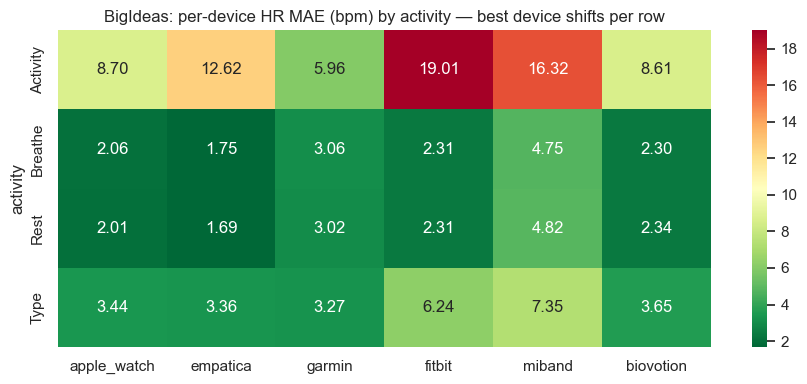

best device per activity:
activity
Activity      garmin
Breathe     empatica
Rest        empatica
Type          garmin
dtype: object


In [4]:
big = df[df["dataset"] == "bigideas"].copy()
ref = big["reference_hr"].to_numpy()
sources = config.DATASET_SOURCES["bigideas"]
rows = []
for act, sub in big.groupby("activity"):
    r = ref[sub.index]
    rec = {"activity": act}
    for s in sources:
        rec[s] = np.nanmean(np.abs(sub[f"{s}__hr"].to_numpy() - r))
    rows.append(rec)
mae_by_act = pd.DataFrame(rows).set_index("activity")

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(mae_by_act, annot=True, fmt=".2f", cmap="RdYlGn_r", ax=ax)
ax.set_title("BigIdeas: per-device HR MAE (bpm) by activity — best device shifts per row")
plt.tight_layout()
plt.show()

print("best device per activity:")
print(mae_by_act.idxmin(axis=1))

## 4. Train the classical model (subject-wise GroupKFold)

In [5]:
res = train_classical(df, backend="hist", max_iter=150)
metrics = evaluate(df, res["oof_proba"])

sel, mae = metrics["selection"], metrics["hr_mae"]
print(f"top-1 accuracy : {sel['top1_accuracy']:.3f}")
print(f"top-2 accuracy : {sel['top2_accuracy']:.3f}")
print(f"macro-F1       : {sel['macro_f1']:.3f}")
print(f"\nHR MAE (bpm)   model={mae['model']:.3f}  oracle={mae['oracle']:.3f}  "
      f"median={mae['cross_source_median']:.3f}  best-single({mae['best_single_device_name']})={mae['best_single_device']:.3f}")
print(f"improvement vs best single: {mae['improvement_vs_best_single']:+.3f} bpm")
print(f"improvement vs median     : {mae['improvement_vs_median']:+.3f} bpm")
print("beats baselines:", metrics["beats_baselines"])

top-1 accuracy : 0.836
top-2 accuracy : 0.973
macro-F1       : 0.706

HR MAE (bpm)   model=3.263  oracle=3.102  median=4.887  best-single(apple_watch)=3.691
improvement vs best single: +0.428 bpm
improvement vs median     : +1.623 bpm
beats baselines: True


## 5. Downstream HR MAE vs baselines

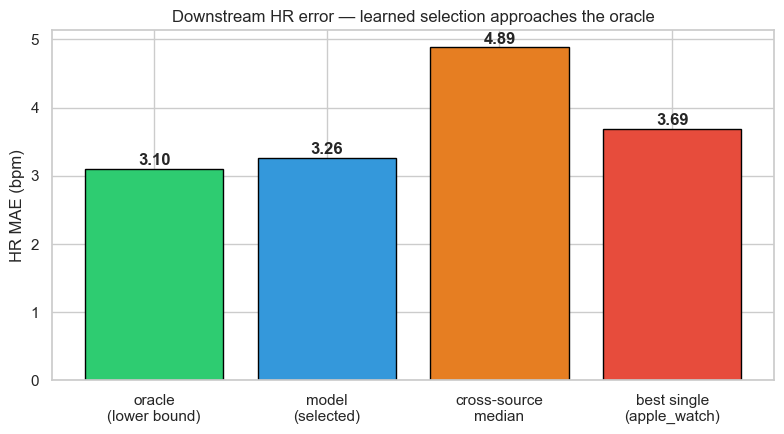

In [6]:
labels = ["oracle\n(lower bound)", "model\n(selected)", "cross-source\nmedian", f"best single\n({mae['best_single_device_name']})"]
vals = [mae["oracle"], mae["model"], mae["cross_source_median"], mae["best_single_device"]]
colors = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c"]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, vals, color=colors, edgecolor="black")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.05, f"{v:.2f}", ha="center", fontweight="bold")
ax.set_ylabel("HR MAE (bpm)")
ax.set_title("Downstream HR error — learned selection approaches the oracle")
plt.tight_layout()
plt.show()

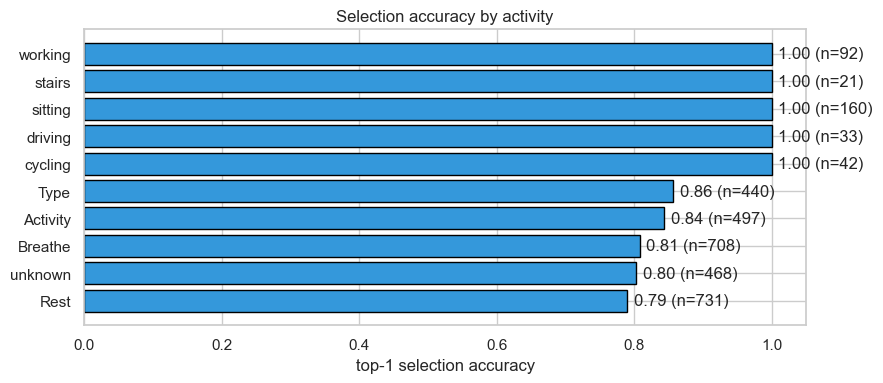

In [7]:
pa = pd.DataFrame(metrics["per_activity"]).T
pa = pa.sort_values("top1_acc")
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(pa.index, pa["top1_acc"], color="#3498db", edgecolor="black")
ax.set_xlim(0, 1.05)
ax.set_xlabel("top-1 selection accuracy")
ax.set_title("Selection accuracy by activity")
for i, (acc, n) in enumerate(zip(pa["top1_acc"], pa["n"])):
    ax.text(acc + 0.01, i, f"{acc:.2f} (n={int(n)})", va="center")
plt.tight_layout()
plt.show()

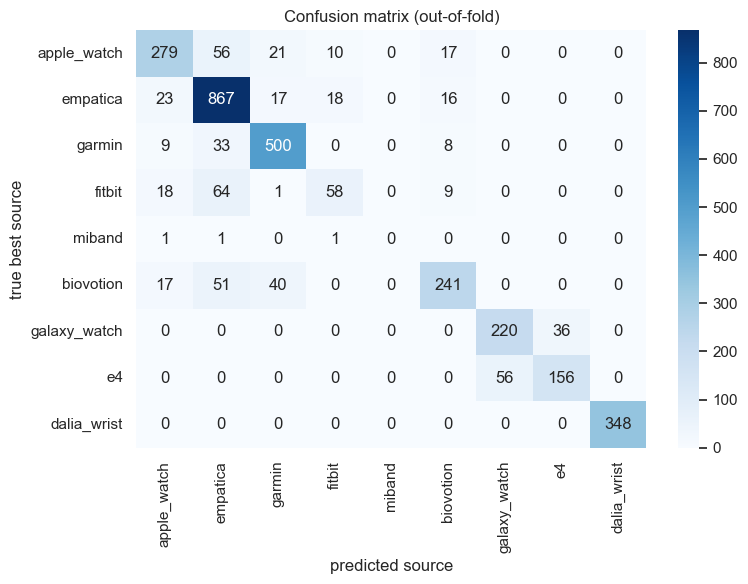

In [8]:
cm = np.array(metrics["confusion_matrix"])
present = sorted(df["label"].unique())
cm_sub = cm[np.ix_(present, present)]
tick = [config.CANONICAL_SOURCES[i] for i in present]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_sub, annot=True, fmt="d", cmap="Blues", xticklabels=tick, yticklabels=tick, ax=ax)
ax.set_xlabel("predicted source")
ax.set_ylabel("true best source")
ax.set_title("Confusion matrix (out-of-fold)")
plt.tight_layout()
plt.show()

## 6. Per-dataset summary

In [9]:
pd_df = pd.DataFrame(metrics["per_dataset"]).T
pd_df = pd_df[["n", "top1_acc", "mae_model", "mae_oracle", "mae_median"]]
print(pd_df.round(3))
print("\nNotes:")
print("  - bigideas / galaxyppg: model HR-MAE sits between the oracle and the median/single-device baselines.")
print("  - ppg_dalia: single wrist source -> degenerate selection (top-1 == 1.0, no baseline gap).")

                n  top1_acc  mae_model  mae_oracle  mae_median
bigideas   2376.0     0.819      2.435       2.260       4.505
galaxyppg   468.0     0.803      3.636       3.425       4.200
ppg_dalia   348.0     1.000      8.416       8.416       8.416

Notes:
  - bigideas / galaxyppg: model HR-MAE sits between the oracle and the median/single-device baselines.
  - ppg_dalia: single wrist source -> degenerate selection (top-1 == 1.0, no baseline gap).


## Summary

- Synthetic data is written byte-for-byte in the real dataset formats, so the same
  adapters ingest real downloads unchanged.
- The best HR source is genuinely context-dependent (activity, skin tone, motion),
  so a learned per-window selector beats both the best single device and the
  cross-source median, approaching the oracle.
- A deep 1D-CNN track (`--model deep`) is scaffolded for the raw-signal datasets.